In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Sample dataset
df = pd.DataFrame({
    "Age": [25, 30, np.nan, 35, 40, 30],
    "Salary": [50000, 60000, 55000, np.nan, 80000, 60000],
    "Department": ["HR", "IT", "HR", "Finance", "IT", "IT"]
})

print("Original Dataset:\n")
print(df)

print("\nMissing Values:\n")
print(df.isnull().sum())

# Remove duplicates
df = df.drop_duplicates()

# Fill missing values
df["Age"] = df["Age"].fillna(df["Age"].mean())
df["Salary"] = df["Salary"].fillna(df["Salary"].mean())

# Encode categorical column
le = LabelEncoder()
df["Department_Encoded"] = le.fit_transform(df["Department"])

# Scale numerical columns
scaler = StandardScaler()
df[["Age_Scaled", "Salary_Scaled"]] = scaler.fit_transform(df[["Age", "Salary"]])

print("\nProcessed Dataset:\n")
print(df.round(2))

Original Dataset:

    Age   Salary Department
0  25.0  50000.0         HR
1  30.0  60000.0         IT
2   NaN  55000.0         HR
3  35.0      NaN    Finance
4  40.0  80000.0         IT
5  30.0  60000.0         IT

Missing Values:

Age           1
Salary        1
Department    0
dtype: int64

Processed Dataset:

    Age   Salary Department  Department_Encoded  Age_Scaled  Salary_Scaled
0  25.0  50000.0         HR                   1        -1.5          -1.10
1  30.0  60000.0         IT                   2        -0.5          -0.12
2  32.5  55000.0         HR                   1         0.0          -0.61
3  35.0  61250.0    Finance                   0         0.5           0.00
4  40.0  80000.0         IT                   2         1.5           1.84


  Student  Marks
0       A     78
1       B     85
2       C     67
3       D     90
4       E     88


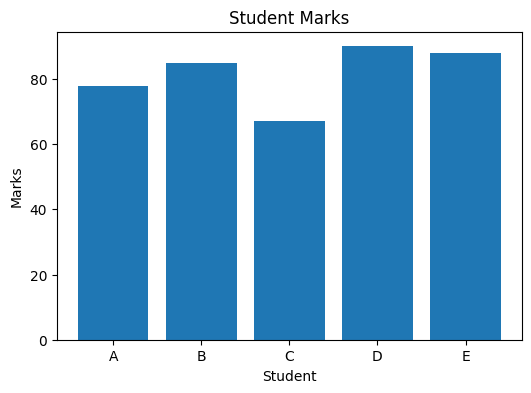

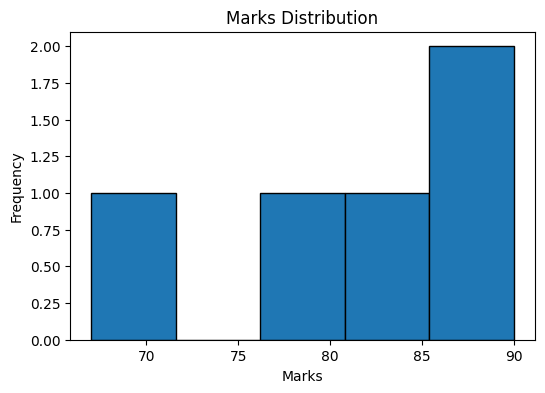

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Sample student marks dataset
df = pd.DataFrame({
    "Student": ["A", "B", "C", "D", "E"],
    "Marks": [78, 85, 67, 90, 88]
})

print(df)

# Bar chart
plt.figure(figsize=(6,4))
plt.bar(df["Student"], df["Marks"])
plt.title("Student Marks")
plt.xlabel("Student")
plt.ylabel("Marks")
plt.show()

# Histogram
plt.figure(figsize=(6,4))
plt.hist(df["Marks"], bins=5, edgecolor="black")
plt.title("Marks Distribution")
plt.xlabel("Marks")
plt.ylabel("Frequency")
plt.show()

In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Sample data: Hours studied vs marks scored
X = np.array([1, 2, 3, 4, 5, 6]).reshape(-1, 1)
y = np.array([45, 50, 55, 60, 65, 70])

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

print("Test Input:", X_test.flatten())
print("Actual Output:", y_test)
print("Predicted Output:", y_pred)

# Evaluation
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

Test Input: [1 2]
Actual Output: [45 50]
Predicted Output: [45. 50.]
Mean Squared Error: 0.0
R2 Score: 1.0


In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Train model
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.0

Confusion Matrix:
 [[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



Cluster Centers:

[[-2.66780392  8.93576069]
 [-6.95170962 -6.67621669]
 [ 4.49951001  1.93892013]]

Cluster Labels (first 10 points):

[1 2 0 2 1 2 0 2 2 0]


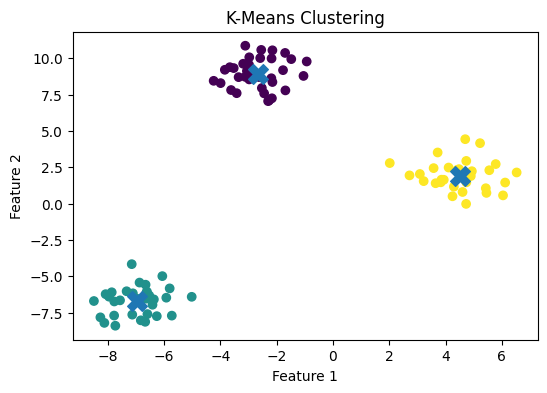

In [ ]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Create sample dataset
X, y = make_blobs(n_samples=100, centers=3, cluster_std=1.0, random_state=42)

# Apply KMeans
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)

print("Cluster Centers:\n")
print(kmeans.cluster_centers_)

print("\nCluster Labels (first 10 points):\n")
print(labels[:10])

# Plot clusters
plt.figure(figsize=(6,4))
plt.scatter(X[:, 0], X[:, 1], c=labels)
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    marker='X',
    s=200
)
plt.title("K-Means Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [ ]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

# Load dataset
data = load_iris()
X = data.data
y = data.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

# Train model
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

# Accuracy
print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.9777777777777777


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

# Load dataset
data = load_iris()
X = data.data
y = data.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3)

# Train model
model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train, y_train)

# Accuracy
print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.9777777777777777


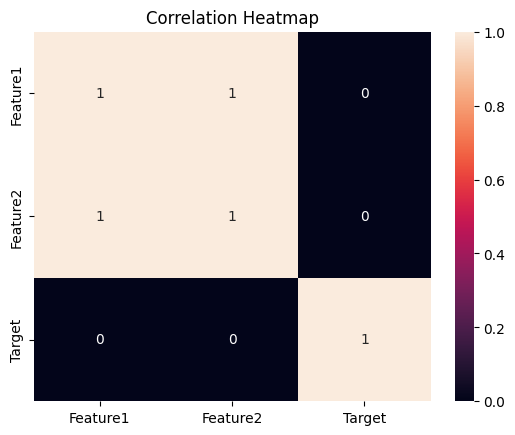

Confusion Matrix:
[[1]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LogisticRegression
import seaborn as sns
import matplotlib.pyplot as plt

# Create dataset
data = {
    "Feature1": [10,20,30,40,50],
    "Feature2": [1,3,5,7,9],
    "Target": [0,1,0,1,0]
}

df = pd.DataFrame(data)

# Correlation Heatmap
sns.heatmap(df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

# Split dataset
X = df[["Feature1","Feature2"]]
y = df["Target"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train model
model = LogisticRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

CSV_FILE = "/content/sales_data.csv"


def create_sample_dataset(path: str = CSV_FILE) -> None:
    """Creates a small sample sales dataset if CSV is not available."""
    data = [
        [1001, "2025-01-03", "South", "Electronics", "Consumer", 15200, 3100],
        [1002, "2025-01-05", "West", "Fashion", "Corporate", 8200, 1250],
        [1003, "2025-01-12", "North", "Grocery", "Consumer", 5400, 760],
        [1004, "2025-02-02", "East", "Electronics", "Home Office", 9800, 2100],
        [1005, "2025-02-11", "South", "Furniture", "Corporate", 11200, 1650],
        [1006, "2025-02-19", "South", "Electronics", "Consumer", 22400, 4700],
        [1007, "2025-03-04", "West", "Fashion", "Consumer", 12800, 2100],
        [1008, "2025-03-14", "North", "Electronics", "Corporate", 27600, 5400],
        [1009, "2025-03-20", "East", "Grocery", "Consumer", 7600, 880],
        [1010, "2025-04-06", "South", "Electronics", "Consumer", 31500, 6900],
        [1011, "2025-04-15", "West", "Furniture", "Corporate", 18800, 2900],
        [1012, "2025-04-22", "North", "Fashion", "Home Office", 10400, 1500],
        [1013, "2025-05-08", "South", "Fashion", "Consumer", 22200, 3200],
        [1014, "2025-05-16", "West", "Electronics", "Corporate", 35200, 7500],
        [1015, "2025-05-24", "East", "Furniture", "Home Office", 14400, 2100],
        [1016, "2025-06-02", "South", "Electronics", "Consumer", 41200, 9100],
        [1017, "2025-06-10", "West", "Fashion", "Corporate", 25400, 3900],
        [1018, "2025-06-20", "North", "Electronics", "Consumer", 38600, 8200],
        [1019, "2025-06-25", "East", "Grocery", "Home Office", 11200, 1600],
        [1020, "2025-06-26", "South", "Furniture", "Corporate", 19800, 3100],
        # Duplicate row for preprocessing demonstration
        [1020, "2025-06-26", "South", "Furniture", "Corporate", 19800, 3100],
        # Missing values for preprocessing demonstration
        [1021, "2025-05-27", "West", "Electronics", "Consumer", np.nan, 2500],
        [1022, "2025-04-27", "East", "Fashion", "Corporate", 9200, np.nan],
    ]
    columns = ["Order_ID", "Date", "Region", "Category", "Segment", "Sales", "Profit"]
    pd.DataFrame(data, columns=columns).to_csv(path, index=False)


def main() -> None:
    # ------------------------------------------------------------------
    # 1. IMPORT AND LOAD DATA
    # ------------------------------------------------------------------
    if not os.path.exists(CSV_FILE):
        create_sample_dataset(CSV_FILE)

    df = pd.read_csv(CSV_FILE)
    print("\n--- DATA PREVIEW ---")
    print(df.head())
    print("Rows and columns:", df.shape)

    # ------------------------------------------------------------------
    # 2. DATA PREPROCESSING
    # ------------------------------------------------------------------
    print("\n--- MISSING VALUES BEFORE CLEANING ---")
    print(df.isnull().sum())

    duplicate_count = df.duplicated().sum()
    df.drop_duplicates(inplace=True)

    df["Date"] = pd.to_datetime(df["Date"])
    df["Month"] = df["Date"].dt.month_name()
    df["Sales"] = df["Sales"].fillna(df["Sales"].mean())
    df["Profit"] = df["Profit"].fillna(0)

    print("\nDuplicate rows removed:", duplicate_count)
    print("Cleaned rows:", len(df))

    # ------------------------------------------------------------------
    # 3. MONTH-WISE SALES ANALYSIS
    # ------------------------------------------------------------------
    month_order = ["January", "February", "March", "April", "May", "June"]
    monthly_sales = df.groupby("Month")["Sales"].sum().reindex(month_order)
    print("\n--- MONTHLY SALES ---")
    print(monthly_sales)

    monthly_sales.plot(kind="bar", title="Monthly Sales Trend")
    plt.xlabel("Month")
    plt.ylabel("Total Sales")
    plt.tight_layout()
    plt.savefig("monthly_sales_trend.png")
    plt.close()

    # ------------------------------------------------------------------
    # 4. CATEGORY-WISE SALES AND PROFIT ANALYSIS
    # ------------------------------------------------------------------
    category_summary = df.groupby("Category")[["Sales", "Profit"]].sum().sort_values("Sales", ascending=False)
    print("\n--- CATEGORY SUMMARY ---")
    print(category_summary)

    category_summary["Sales"].plot(kind="pie", autopct="%1.1f%%", title="Category Sales Share")
    plt.ylabel("")
    plt.tight_layout()
    plt.savefig("category_sales_share.png")
    plt.close()

    # ------------------------------------------------------------------
    # 5. REGION-WISE PERFORMANCE ANALYSIS
    # ------------------------------------------------------------------
    region_summary = df.groupby("Region").agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Orders=("Order_ID", "count")
    ).sort_values("Sales", ascending=False)
    print("\n--- REGION SUMMARY ---")
    print(region_summary)

    region_summary["Sales"].plot(kind="barh", title="Region-wise Sales")
    plt.xlabel("Total Sales")
    plt.tight_layout()
    plt.savefig("region_wise_sales.png")
    plt.close()

    # ------------------------------------------------------------------
    # 6. CUSTOMER SEGMENT ANALYSIS
    # ------------------------------------------------------------------
    segment_sales = df.groupby("Segment")["Sales"].sum().sort_values(ascending=False)
    print("\n--- CUSTOMER SEGMENT SALES ---")
    print(segment_sales)

    segment_sales.plot(kind="bar", title="Sales by Customer Segment")
    plt.xlabel("Customer Segment")
    plt.ylabel("Sales")
    plt.tight_layout()
    plt.savefig("customer_segment_sales.png")
    plt.close()

    # ------------------------------------------------------------------
    # 7. DASHBOARD SUMMARY METRICS
    # ------------------------------------------------------------------
    total_sales = df["Sales"].sum()
    total_profit = df["Profit"].sum()
    avg_order_value = df["Sales"].mean()
    top_region = df.groupby("Region")["Sales"].sum().idxmax()
    top_category = df.groupby("Category")["Sales"].sum().idxmax()

    print("\n--- DASHBOARD METRICS ---")
    print("Total Sales:", round(total_sales, 2))
    print("Total Profit:", round(total_profit, 2))
    print("Average Order Value:", round(avg_order_value, 2))
    print("Top Region:", top_region)
    print("Top Category:", top_category)

    # ------------------------------------------------------------------
    # 8. BASIC SALES FORECASTING
    # ------------------------------------------------------------------
    month_numbers = np.arange(1, len(monthly_sales.dropna()) + 1).reshape(-1, 1)
    sales_values = monthly_sales.dropna().values

    model = LinearRegression()
    model.fit(month_numbers, sales_values)
    predicted_next_month = model.predict([[len(sales_values) + 1]])[0]

    print("\n--- BASIC FORECAST ---")
    print("Predicted next month sales:", round(predicted_next_month, 2))

    print("\nCharts saved as PNG files in the current folder.")


if __name__ == "__main__":
    main()



--- DATA PREVIEW ---
   Order_ID        Date Region     Category      Segment    Sales  Profit
0      1001  2025-01-03  South  Electronics     Consumer  15200.0  3100.0
1      1002  2025-01-05   West      Fashion    Corporate   8200.0  1250.0
2      1003  2025-01-12  North      Grocery     Consumer   5400.0   760.0
3      1004  2025-02-02   East  Electronics  Home Office   9800.0  2100.0
4      1005  2025-02-11  South    Furniture    Corporate  11200.0  1650.0
Rows and columns: (23, 7)

--- MISSING VALUES BEFORE CLEANING ---
Order_ID    0
Date        0
Region      0
Category    0
Segment     0
Sales       1
Profit      1
dtype: int64

Duplicate rows removed: 1
Cleaned rows: 22

--- MONTHLY SALES ---
Month
January      28800.000000
February     43400.000000
March        48000.000000
April        69900.000000
May          90757.142857
June        136200.000000
Name: Sales, dtype: float64

--- CATEGORY SUMMARY ---
                     Sales   Profit
Category                           
El